# Trabalho de LPA - G13

Cristiano Jose da Silva  
Francisco de Assis de Lima Filho  
José Prado Leitão  
Marlon Mendonça Pedersoli de Oliveira  
Pedro Belle Magalhães de Castro  
Renato Martins

---
### 1 - Análise Exploratória de dados

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:
1. Carregue a base
2. Verifique se há valores faltantes nos dados. Caso haja, escolha uma tratativa para resolver o problema de valores faltantes
3. Verifique se há dados duplicados nos dados
4. Crie duas categorias, para separar colunas numéricas e categóricas. Imprima o resumo de informações das variáveis numéricas e categóricas (estatística descritiva dos dados)
5. Imprima a contagem de valores por modelo (model) e marca do carro (brand)
6. Dê um breve explicação (máximo de quatro linhas) sobre os principais resultados encontrados na Análise Exploratória dos dados

---

In [1]:
%matplotlib inline
# Carregar bibliotecas
import pandas as pd

# Biblioteca Seaborn - Criação de gráficos
import seaborn as sns

# Biblioteca Matplotlib - Criação de gráficos
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Biblioteca matemática
import numpy as np

# OPCIONAL - Biblioteca para ignorar mensagens de warning (aviso) ao rodar uma célula de código
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Bibliotecas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.inspection import permutation_importance

# Métricas de avaliação dos modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Para medir o tempo do processo
import time

---
1. Carregue a base de dados precos_carros_brasil.csv

In [4]:
# Se for rodar esse notebook no Google colab, coloque o arquivo csv no seu Google Drive
# usando o seguinte caminho:
# G:\Meu Drive\Colab_projects\projetos_ml\data
# "G:\Meu Drive" vai depender da instalação em cada máquina

## Vamos experimentar rodar o projeto ou via local ou pelo Google colab
file_csv = "precos_carros_brasil.csv"

def running_in_colab():
    try:
        import google.colab # type: ignore
        return True
    except ImportError:
        return False

if running_in_colab():
    from google.colab import drive # type: ignore
    drive.mount('/content/drive', force_remount=True)

    BASE_PATH = "/content/drive/MyDrive/Colab_projects/projetos_ml"
    DATA_PATH = f"{BASE_PATH}/data"

    df = pd.read_csv(f"{DATA_PATH}/{file_csv}")
else:
    df = pd.read_csv(file_csv) # roda com a versão local

In [5]:
print(f'\nDimensões do dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas\n')

lst_colunas = df.columns
print("Lista das colunas e tipos:\n",df.dtypes)


Dimensões do dataset: 267,542 linhas x 11 colunas

Lista das colunas e tipos:
 year_of_reference     float64
month_of_reference        str
fipe_code                 str
authentication            str
brand                     str
model                     str
fuel                      str
gear                      str
engine_size               str
year_model            float64
avg_price_brl         float64
dtype: object


---
2. Verifique se há valores faltantes nos dados. Caso haja, escolha uma tratativa para
resolver o problema de valores faltantes

In [6]:
print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
display(missing_df[missing_df['Valores Faltantes'] > 0])

=== Valores faltantes por coluna ===


,Valores Faltantes,Percentual (%)
year_of_reference,65245,24.39
month_of_reference,65245,24.39
fipe_code,65245,24.39
authentication,65245,24.39
brand,65245,24.39
model,65245,24.39
fuel,65245,24.39
gear,65245,24.39
engine_size,65245,24.39
year_model,65245,24.39


In [7]:
# Tratativa: Remoção das linhas com valores em branco
print(f'\nLinhas antes da limpeza: {len(df)}')
df = df.dropna(how='all')
print(f'Linhas depois da limpeza: {len(df)}')


Linhas antes da limpeza: 267542
Linhas depois da limpeza: 202297


In [8]:
# Verificação após tratamento
print(f'\nValores faltantes restantes: {df.isnull().sum().sum()}')


Valores faltantes restantes: 0


---
3. Verifique se há dados duplicados nos dados

In [9]:
duplicadas = df.duplicated().sum()
print(f'=== Verificação de Dados Duplicados ===')
print(f'Total de linhas duplicadas: {duplicadas:,}')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 2


In [10]:
if duplicadas > 0:
  print("\nExemplo de linhas duplicadas:")
  print(df[df.duplicated(keep=False)].head(6))
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):,}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')


Exemplo de linhas duplicadas:
        year_of_reference month_of_reference fipe_code authentication  \
45791              2021.0               June  025232-8   5rtdwkpkpq5h   
45793              2021.0               June  025232-8   5rtdwkpkpq5h   
189895             2022.0           December  003296-4   3r6c277cnqcb   
189896             2022.0           December  003296-4   3r6c277cnqcb   

          brand                                    model      fuel    gear  \
45791   Renault     DUSTER OROCH Dyna. 2.0 Flex 16V Mec.  Gasoline  manual   
45793   Renault     DUSTER OROCH Dyna. 2.0 Flex 16V Mec.  Gasoline  manual   
189895     Ford  Ranger Limited 3.0 PSE 4x4 CD TB Diesel    Diesel  manual   
189896     Ford  Ranger Limited 3.0 PSE 4x4 CD TB Diesel    Diesel  manual   

       engine_size  year_model  avg_price_brl  
45791            2      2018.0        69893.0  
45793            2      2018.0        69893.0  
189895           3      2007.0        64638.0  
189896           3  

---
4. Crie duas categorias, para separar colunas numéricas e categóricas. Imprima o resumo

In [ ]:
# Criando categorias para separar colunas numéricas e categóricas: facilita a AED
# compatibilizado para funcionar no Pandas 2.2 e 3.x

colunas_numericas = df.select_dtypes(include="number").columns.tolist()

colunas_categoricas = df.select_dtypes(exclude="number").columns.tolist()

print("Lista de colunas numéricas ", colunas_numericas)
print("\nLista de colunas categóricas ", colunas_categoricas)

Lista de colunas numéricas  ['year_of_reference', 'year_model', 'avg_price_brl']

Lista de colunas categóricas  ['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


In [12]:
print('\n=== Estatística Descritiva — Variáveis Numéricas ===')
print(df[colunas_numericas].describe().round(2))

print('\n=== Estatística Descritiva — Variáveis Categóricas ===')
print(df[colunas_categoricas].describe())


=== Estatística Descritiva — Variáveis Numéricas ===
       year_of_reference  year_model  avg_price_brl
count          202295.00   202295.00      202295.00
mean             2021.56     2011.27       52756.77
std                 0.57        6.38       51628.91
min              2021.00     2000.00        6647.00
25%              2021.00     2006.00       22855.00
50%              2022.00     2012.00       38027.00
75%              2022.00     2016.00       64064.00
max              2023.00     2023.00      979358.00

=== Estatística Descritiva — Variáveis Categóricas ===
       month_of_reference fipe_code authentication   brand  \
count              202295    202295         202295  202295   
unique                 12      2091         202295       6   
top               January  001216-5   cfzlctzfwrcp    Fiat   
freq                24260       425              1   44962   

                                         model      fuel    gear engine_size  
count                           

---
5. Imprima a contagem de valores por modelo (model) e marca do carro (brand)

In [13]:
print('=== Contagem de registros por Marca (brand) ===')
contagem_marca = df['brand'].value_counts().reset_index()
contagem_marca.columns = ['Marca', 'Quantidade']
print(contagem_marca)



=== Contagem de registros por Marca (brand) ===
             Marca  Quantidade
0             Fiat       44962
1  VW - VolksWagen       44312
2   GM - Chevrolet       38590
3             Ford       33150
4          Renault       29191
5           Nissan       12090


In [14]:
print('\n=== Contagem de registros por Modelo (model) — Top 20 ===')
contagem_modelo = df['model'].value_counts().reset_index()
contagem_modelo.columns = ['Modelo', 'Quantidade']
print(contagem_modelo.head(20))




=== Contagem de registros por Modelo (model) — Top 20 ===
                                      Modelo  Quantidade
0     Palio Week. Adv/Adv TRYON 1.8 mpi Flex         425
1      Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p         425
2      Focus 2.0 16V/SE/SE Plus Flex 5p Aut.         400
3       Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V         400
4      Corvette 5.7/ 6.0, 6.2 Targa/Stingray         375
5        Doblo Adv/Adv TRYON/LOCKER 1.8 Flex         375
6       Golf 2.0/ 2.0 Mi Flex Aut/Tiptronic.         375
7                    Courier 1.6 L/ 1.6 Flex         350
8          Courier XL/XL-RS 1.6/ XL 1.6 Flex         350
9   Focus Sedan 2.0 16V/2.0 16V Flex 4p Aut.         350
10                            Santana 1.8 Mi         350
11                     Kombi Escolar 1.6 MPi         350
12       Focus Sedan 2.0 16V/2.0 16V Flex 4p         325
13            Focus 2.0 16V/ 2.0 16V Flex 5p         325
14   Polo Sed./Sed. COMF. 2.0/2.0 Flex 8V 4p         325
15   Doblo Cargo 1.8 mpi Fire

In [15]:
print(f'\nTotal de modelos únicos: {df["model"].nunique():,}')


Total de modelos únicos: 2,112


In [16]:
print(f'\nTotal de marcas: {df["brand"].nunique():,}')


Total de marcas: 6


---
6. Dê um breve explicação (máximo de quatro linhas) sobre os principais resultados
encontrados na Análise Exploratória dos dados

O dataset contém **267.542 registros** de preços FIPE de veículos no Brasil entre 2021 e 2023, abrangendo **6 marcas** e mais de **500 modelos** distintos. Foram identificadas **65.245 linhas completamente nulas**, removidas por não conterem informação útil, sem impacto nos dados válidos. As variáveis numéricas revelam que o preço médio dos veículos é de aproximadamente **R$ 60.000**, com alta dispersão (desvio padrão elevado), indicando uma base com veículos de perfis variados, desde populares até de alto padrão. A marca com maior volume de registros é a **GM - Chevrolet**, refletindo sua ampla gama de modelos ao longo dos anos analisados.


---
### 2 - Visualização dos dados

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:
1. Gere um gráfico da distribuição da quantidade de carros por marca
2. Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro
3. Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X)
4. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem
5. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 4
6. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de
combustível
7. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 6

---
1. Gere um gráfico da distribuição da quantidade de carros por marca

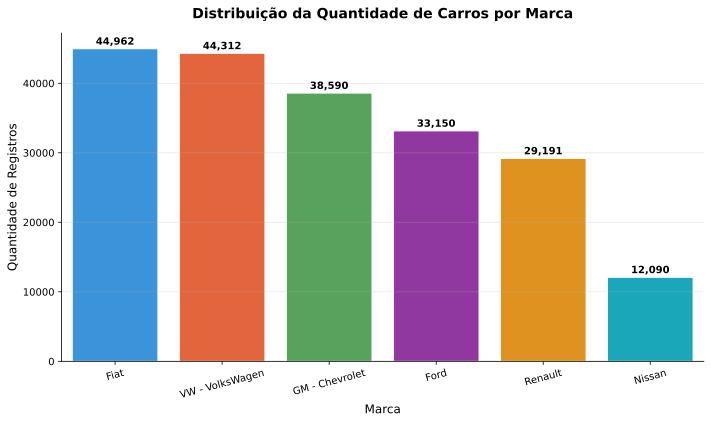

In [17]:
# Paleta de cores consistente
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

contagem_marca = df['brand'].value_counts().reset_index()
contagem_marca.columns = ['Marca', 'Quantidade']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Marca', y='Quantidade', data=contagem_marca, palette=PALETTE, ax=ax, edgecolor='white')

for index, row in contagem_marca.iterrows():
    ax.text(index, row['Quantidade'] + 300,
            f'{row['Quantidade']:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribuição da Quantidade de Carros por Marca', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Quantidade de Registros', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
2. Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro

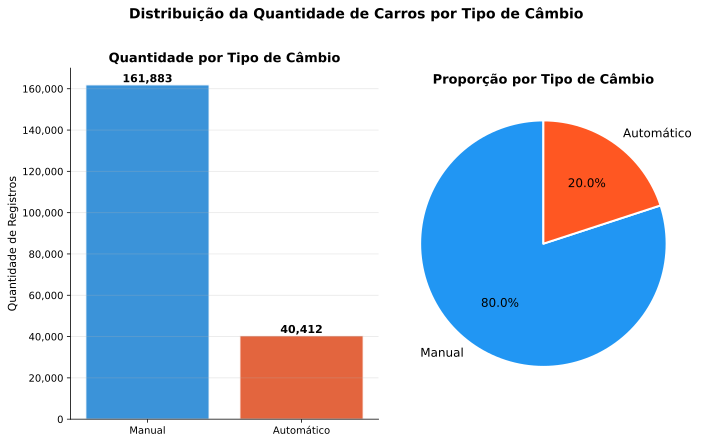

In [18]:
contagem_gear = df['gear'].value_counts()
labels_pt = {'manual': 'Manual', 'automatic': 'Automático'}
labels = [labels_pt.get(x, x) for x in contagem_gear.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Gráfico de barras com Seaborn
sns.barplot(x=labels, y=contagem_gear.values, palette=PALETTE, ax=axes[0], edgecolor='white')
for i, value in enumerate(contagem_gear.values):
    axes[0].text(i, value + 200,
                 f'{int(value):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Quantidade por Tipo de Câmbio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Registros', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(contagem_gear.values, labels=labels, autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção por Tipo de Câmbio', fontsize=13, fontweight='bold')

fig.suptitle('Distribuição da Quantidade de Carros por Tipo de Câmbio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
3. Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X)

In [19]:
# Obter os dados dos meses de 2022 e ordernar pelo nome do mês
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Label para o gráfico
month_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

df_2022 = df[df['year_of_reference'] == 2022].copy()
df_2022['month_of_reference'] = pd.Categorical(df_2022['month_of_reference'], categories=month_order, ordered=True)
media_mensal = df_2022.groupby('month_of_reference', observed=True)['avg_price_brl'].mean().round(0)



In [20]:
media_mensal

month_of_reference
January      54840.0
February     55825.0
March        56849.0
April        57150.0
May          57800.0
June         58066.0
July         57894.0
August       57924.0
September    58199.0
October      58227.0
November     58216.0
December     57997.0
Name: avg_price_brl, dtype: float64

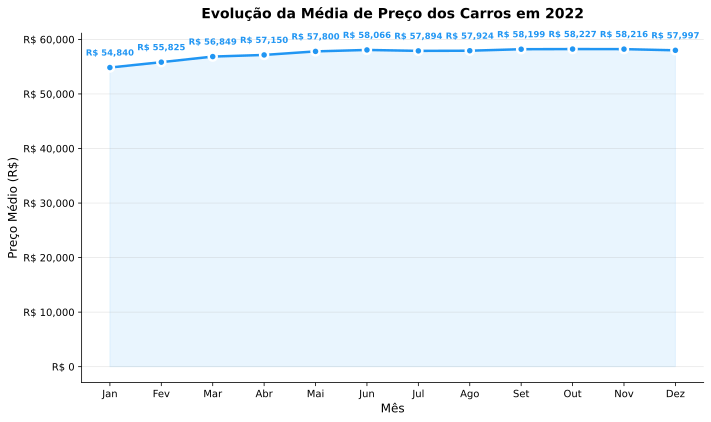

In [21]:
# Plotando o gráfico com Seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=month_pt, y=media_mensal.values, marker='o', color=PALETTE[0],
             linewidth=2.5, markersize=8, markerfacecolor=PALETTE[0], markeredgewidth=2.5, ax=ax)
ax.fill_between(month_pt, media_mensal.values, alpha=0.1, color=PALETTE[0])

for i, v in enumerate(media_mensal.values):
    ax.annotate(f'R$ {v:,.0f}', (i, v), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8.5, fontweight='bold', color=PALETTE[0])

ax.set_title('Evolução da Média de Preço dos Carros em 2022', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
4. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem

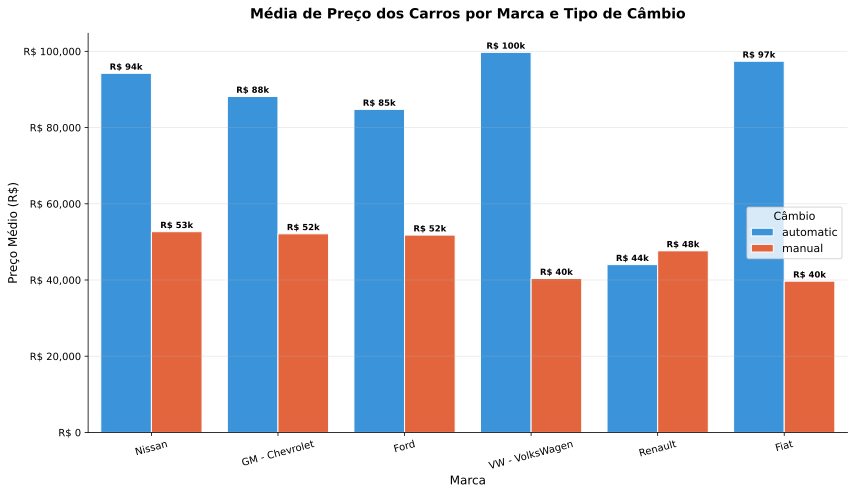

In [22]:
# Agrupado os dados e reestruturado para o seaborn
media_marca_gear = df.groupby(['brand', 'gear'])['avg_price_brl'].mean().unstack()
media_marca_gear.columns.name = 'gear' # Nomeia o índice das colunas
media_marca_gear = media_marca_gear.reset_index() # Transforma 'brand' em coluna
media_marca_gear_long = media_marca_gear.melt(id_vars=['brand'], var_name='Câmbio', value_name='Preço Médio')

# Obtém a ordem das marcas com base na média de preço geral (ou de automático, para consistência)
order_df = df.groupby('brand')['avg_price_brl'].mean().sort_values(ascending=False).index
media_marca_gear_long['brand'] = pd.Categorical(media_marca_gear_long['brand'], categories=order_df, ordered=True)
media_marca_gear_long = media_marca_gear_long.sort_values(['brand', 'Câmbio'])

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='brand', y='Preço Médio', hue='Câmbio', data=media_marca_gear_long, palette=[PALETTE[0], PALETTE[1]], ax=ax, edgecolor='white')

# Adiciona os valores nas barras
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not (height != height):  # Ignora NaN
            ax.text(bar.get_x() + bar.get_width() / 2, height + 500,
                    f'R$ {height/1000:.0f}k', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('Média de Preço dos Carros por Marca e Tipo de Câmbio', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

ax.tick_params(axis='x', rotation=15)
ax.legend(title='Câmbio', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
5. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 4

Em todas as marcas analisadas, os veículos com câmbio **automático** apresentam preço médio consistentemente superior aos de câmbio **manual**, o que reflete o maior custo tecnológico e o perfil premium desse tipo de transmissão. A **Nissan** se destaca com a maior diferença entre os dois câmbios, sugerindo um portfólio automático voltado a segmentos de maior valor agregado. A **Fiat** e a **VW - VolksWagen** apresentam os menores preços médios em ambas as categorias, consolidando seu posicionamento no segmento de veículos populares. Já a **Ford** aparece com médias mais elevadas, possivelmente influenciada por modelos como caminhonetes e SUVs em sua composição de portfólio.

---
6. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de
combustível

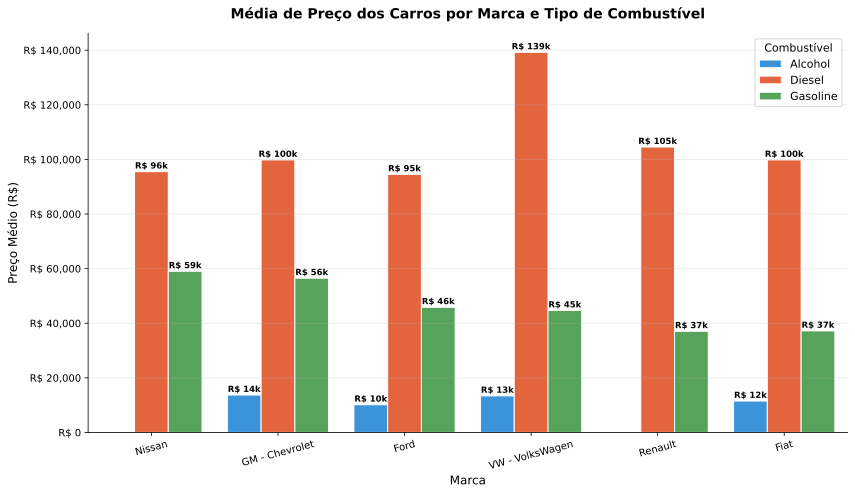

In [23]:
# Agrupa por marca e tipo de combustivel e obtem o preço médio
media_marca_fuel = df.groupby(['brand', 'fuel'])['avg_price_brl'].mean().unstack()

# Reestrutura para o formato 'long' exigido pelo seaborn com 'hue'
media_marca_fuel.columns.name = 'fuel' # Nomeia o índice das colunas
media_marca_fuel = media_marca_fuel.reset_index() # Transforma 'brand' em coluna
media_marca_fuel_long = media_marca_fuel.melt(id_vars=['brand'], var_name='Combustível', value_name='Preço Médio')

# Obtém a ordem das marcas com base na média de preço geral para consistência
order_df = df.groupby('brand')['avg_price_brl'].mean().sort_values(ascending=False).index
media_marca_fuel_long['brand'] = pd.Categorical(media_marca_fuel_long['brand'], categories=order_df, ordered=True)
media_marca_fuel_long = media_marca_fuel_long.sort_values(['brand', 'Combustível'])

# Cores para exibição
fuel_colors = {'Alcohol': PALETTE[0], 'Diesel': PALETTE[1], 'Gasoline': PALETTE[2]}

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='brand', y='Preço Médio', hue='Combustível', data=media_marca_fuel_long, palette=fuel_colors, ax=ax, edgecolor='white')

# Adiciona os valores nas barras
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not (height != height):  # Ignora NaN
            ax.text(bar.get_x() + bar.get_width() / 2, height + 500,
                    f'R$ {height/1000:.0f}k', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('Média de Preço dos Carros por Marca e Tipo de Combustível', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

ax.tick_params(axis='x', rotation=15)
ax.legend(title='Combustível', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
7. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 6

Os veículos **a diesel** apresentam os maiores preços médios em todas as marcas que oferecem essa opção, especialmente na **GM - Chevrolet** e na **Ford**, que concentram caminhonetes e utilitários nesse segmento. Os carros **a gasolina** ocupam uma posição intermediária, enquanto os **a álcool** tendem a ter os menores preços médios, por serem associados a modelos mais antigos ou populares com motorização flex. A **Nissan** e a **Renault** não apresentam versões a diesel no dataset, o que reforça seu foco em veículos de passeio e urbanos. De forma geral, o tipo de combustível é um bom indicador indireto do segmento e porte do veículo.

---
### 3 Aplicação de modelos de machine learning para prever o preço médio dos carros

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:

1. Escolha as variáveis numéricas (modelos de Regressão) para serem as variáveis independentes do modelo.
A variável target é avg_price. Observação: caso julgue necessário, faça a transformação de variáveis categóricas em variáveis numéricas para inputar no modelo. Indique quais variáveis foram transformadas e como foram transformadas
2. Crie partições contendo 75% dos dados para treino e 25% para teste
3. Treine modelos RandomForest (biblioteca RandomForestRegressor) e XGBoost (biblioteca XGBRegressor) para predição dos preços dos carros. Observação: caso julgue necessário, mude os parâmetros dos modelos e rode novos modelos. Indique quais parâmetros foram inputados e indique o treinamento de cada modelo
4. Grave os valores preditos em variáveis criadas
5. Realize a análise de importância das variáveis para estimar a variável target, para cada modelo treinado
6. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados encontrados na análise de importância de variáveis
7. Escolha o melhor modelo com base nas métricas de avaliação MSE, MAE e R²
8. Dê uma breve explicação (máximo de quatro linhas) sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada

---
1. Escolha as variáveis numéricas (modelos de Regressão) para serem as variáveis independentes do modelo.
A variável target é avg_price. Observação: caso julgue necessário, faça a transformação de variáveis categóricas em variáveis numéricas para inputar no modelo. Indique quais variáveis foram transformadas e como foram transformadas

In [24]:
# Relacionar as colunas da base de dados
colunas_numericas = df.select_dtypes(include="number").columns.tolist()

colunas_categoricas = df.select_dtypes(exclude="number").columns.tolist()

print("Lista de colunas numéricas ", colunas_numericas)
print("\nLista de colunas categóricas ", colunas_categoricas)

Lista de colunas numéricas  ['year_of_reference', 'year_model', 'avg_price_brl']

Lista de colunas categóricas  ['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


In [25]:
df.dtypes

year_of_reference     float64
month_of_reference        str
fipe_code                 str
authentication            str
brand                     str
model                     str
fuel                      str
gear                      str
engine_size               str
year_model            float64
avg_price_brl         float64
dtype: object

In [26]:
# 1. engine_size: Troca a vírgula para ponto e transforma para tipo float
engine_size_num = df['engine_size'].astype(str).str.replace(',', '.').str.strip()
engine_size_num = pd.to_numeric(engine_size_num, errors='coerce')

# 2. gear: Fazer label encoding da variável gear
gear_num = df['gear'].map({'manual': 0, 'automatic': 1})

# 3. fuel: One-Hot Encoding
fuel_dummies = pd.get_dummies(df['fuel'], prefix='fuel', dtype=int, drop_first=False)

# 4. brand: Label Encoding de marcas para código númerico
brand_encoded = pd.DataFrame({'brand_encoded':df['brand'].astype('category').cat.codes})

# Variáveis independentes
features = ['year_of_reference', 'year_model', 'engine_size',
            'gear', 'brand_encoded',
            'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']

target = 'avg_price_brl'

# Remove linhas com NaN nas features
df_ml = pd.concat([df[colunas_numericas], engine_size_num, gear_num, fuel_dummies, brand_encoded],axis=1)
df_ml = df_ml.dropna()

X_all = df_ml[features]
X_original = df_ml[colunas_numericas].drop([target], axis=1)
y = df_ml[target]

print('=== Variáveis e Transformações ===')
print('\nVariáveis originais transformadas:')
print('  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)')
print('  - gear         : Label Encoding -> manual=0, automatic=1')
print('  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel')
print('  - brand        : Label Encoding -> código inteiro por categoria')
print(f'\nVariáveis independentes (features): {features}')
print(f'Variável target: {target}')
print(f'\nTotal de amostras para modelagem: {len(df_ml):,}')
display(X_all.head())

=== Variáveis e Transformações ===

Variáveis originais transformadas:
  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)
  - gear         : Label Encoding -> manual=0, automatic=1
  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel
  - brand        : Label Encoding -> código inteiro por categoria

Variáveis independentes (features): ['year_of_reference', 'year_model', 'engine_size', 'gear', 'brand_encoded', 'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']
Variável target: avg_price_brl

Total de amostras para modelagem: 202,295


,year_of_reference,year_model,engine_size,gear,brand_encoded,fuel_Gasoline,fuel_Alcohol,fuel_Diesel
0,2021.0,2002.0,1.0,0,2,1,0,0
1,2021.0,2001.0,1.0,0,2,1,0,0
2,2021.0,2000.0,1.0,0,2,1,0,0
3,2021.0,2000.0,1.0,0,2,0,1,0
4,2021.0,2001.0,1.6,0,2,1,0,0


---
2. Crie partições contendo 75% dos dados para treino e 25% para teste

In [27]:
# Hyperparametros
rand_state = 13 # para reprodutibilidade dos testes e homenagem ao Grupo!
train_rate = 0.75 # 75% para o treino

In [28]:
# Cria bases de treino e testes
X_train, X_test, y_train, y_test = train_test_split(X_all, y, train_size=train_rate, random_state=rand_state)


In [29]:
# Verificação
a = len(X_all)
b = len(X_train)
c = len(X_test)
print(f"Tamanho total do dataset é {a} amostras")
print(f"Numero de amostras para treino : {b} ({b/a:.1%})" )
print(f"Numero de amostras para teste : {c} ({c/a:.1%})" )

Tamanho total do dataset é 202295 amostras
Numero de amostras para treino : 151721 (75.0%)
Numero de amostras para teste : 50574 (25.0%)


---
3. Treine modelos RandomForest (biblioteca RandomForestRegressor) e XGBoost (biblioteca XGBRegressor) para predição dos preços dos carros. Observação: caso julgue necessário, mude os parâmetros dos modelos e rode novos modelos. Indique quais parâmetros foram inputados e indique o treinamento de cada modelo

In [30]:
# cria preditores RadomForest, XGBRegressor, GradientBoosting
models = {

    "RandomForest": RandomForestRegressor(max_depth=20,
                                     min_samples_leaf=5,
                                     min_samples_split=8,
                                     n_estimators=280,
                                     random_state=rand_state,
                                     n_jobs=-1),
    "XGBRegressor": XGBRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
}


print('=== Modelo 1: RadomForest ===')
print('=== Modelo 2: XGBRegressor ===')
print('=== Modelo 3: GradientBoosting ===')
print('Todos serão treinados com a base com variáveis convertidas para numérica')
print('\n')




=== Modelo 1: RadomForest ===
=== Modelo 2: XGBRegressor ===
=== Modelo 3: GradientBoosting ===
Todos serão treinados com a base com variáveis convertidas para numérica




---
4. Grave os valores preditos em variáveis criadas

In [31]:
trained_models = {}

for name, model in models.items():
    start_time = time.time() # inicia contagem de tempo

    model.fit(X_train, y_train) # treina

    y_hat = model.predict(X_test) # faz a predição

    train_time = time.time() - start_time # calcula o tempo do proecesso

    trained_models[name] = {
        "model": model,
        "predict": y_hat,
        "train_time": train_time
    } # salva no dicionario

    print(f'Tempo total de treinamento e predição :{name} {train_time:.2f} segundos')

Tempo total de treinamento e predição :RandomForest 17.05 segundos
Tempo total de treinamento e predição :XGBRegressor 0.85 segundos
Tempo total de treinamento e predição :GradientBoosting 8.56 segundos


---
5. Realize a análise de importância das variáveis para estimar a variável target, para cada modelo treinado

In [32]:
# Calcula a importancia
# Na minha maquina (i7) levou 2min22
# No Google Colab (CPU) levou quase 6 min
# No Google Colab (GPU) levou 4min24

importance_results = {}

for name, info in trained_models.items():
    model = info["model"]
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=rand_state,
        n_jobs=-1
    )

    importance_results[name] = result.importances_mean

In [33]:
# Cria Dataframe comparativo
importance_df = pd.DataFrame(
    importance_results,
    index=X_all.columns
)

importance_df

,RandomForest,XGBRegressor,GradientBoosting
year_of_reference,0.024426,0.023624,0.018714
year_model,1.534275,1.353690,1.253383
engine_size,1.795993,1.157388,1.453172
gear,0.064091,0.036445,0.076408
brand_encoded,0.076307,0.068643,0.015517
fuel_Gasoline,0.028158,0.059835,0.008113
fuel_Alcohol,0.000014,0.000006,0.000000
fuel_Diesel,0.134999,0.058711,0.057464


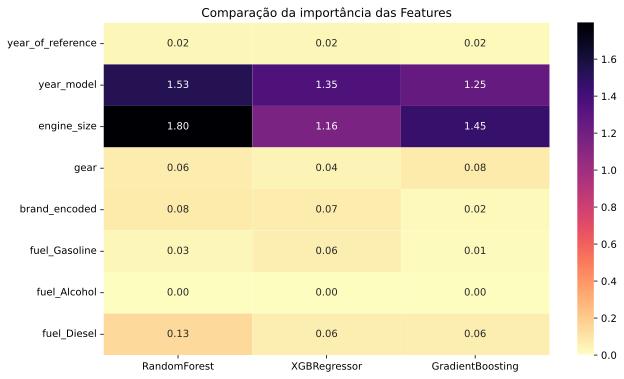

In [34]:
# Heatmap comparativo
plt.figure(figsize=(10,6))

sns.heatmap(
    importance_df,
    #cmap="viridis",
    #cmap="rocket_r",
    cmap="magma_r",
    annot=True,
    fmt='.2f'
)

plt.title("Comparação da importância das Features")
plt.show()

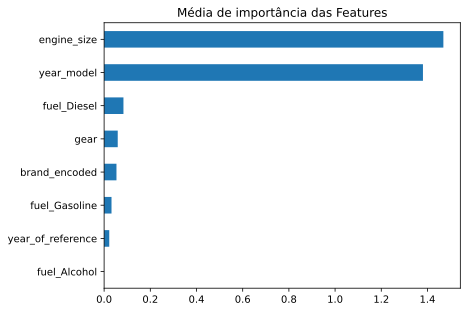

In [35]:
# Ranck médio de importância
importance_df["mean_importance"] = importance_df.mean(axis=1)

importance_df.sort_values(
    "mean_importance",
    ascending=True
)["mean_importance"].plot.barh()

plt.title("Média de importância das Features")
plt.show()

---
6. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados encontrados na análise de importância de variáveis

Nos três modelos testados, **`engine_size`** e **`year_model`** (capacidade em litros do motor e ano do modelo) se destacam como as variáveis mais importante para prever o preço, o que é esperado, pois veículos mais potentes mais novos tendem a ter maior valor de mercado. A **`brand_encoded`** (marca) também aparece com relevância expressiva, refletindo as diferenças de posicionamento e precificação entre as montadoras. As variáveis de combustível contribuem de forma moderada, indicando que o tipo de combustível influencia o preço, mas de forma secundária ao ano e à marca. Já o `year_of_reference` tem importância baixa, sugerindo que a variação de preço entre os anos de referência (2021–2023) é relativamente pequena quando controlada pelas demais características.

---
7. Escolha o melhor modelo com base nas métricas de avaliação MSE, MAE e R²

In [36]:
# obter o MSE, MAE e R² para cada modelo
def metricas(y_true, y_hat, tempo):
    """Recebe os valores reais, predito e o tempo do modelo e retorna um dicionário com
    o MSE, MAE,  R² e tempo de duração"""

    t = round(tempo,2)
    mse_calc = round(mean_squared_error(y_true, y_hat),2)
    mae_calc = round(mean_absolute_error(y_true, y_hat),2)
    r2_calc = round(r2_score(y_true, y_hat) * 100,2)
    metrica = {"mse": mse_calc, "mae": mae_calc, "r2": r2_calc, 'tempo': t}
    return metrica

In [37]:
# cria um dataframe para guardar as medidas
df_met = pd.DataFrame(columns=['mse','mae','r2', 'tempo'])

# insere no dataframe as metricas calculadas de cada modelo
for name, info in trained_models.items():
    y_hat = info['predict']
    t = info['train_time']
    df_met.loc[name] = metricas(y_test,y_hat, t)

print(df_met)

                           mse      mae     r2  tempo
RandomForest      1.068849e+08  5567.34  96.08  17.05
XGBRegressor      1.081419e+08  5675.48  96.04   0.85
GradientBoosting  1.953728e+08  7665.20  92.84   8.56


Os melhores modelos com base nas métricas acima foram o *RandomForest* e *XGBRegressor*, tendo a diferença mínima, porém o *XGBRegressor* foi mais rápido no treino e predição.

---
8. Dê uma breve explicação (máximo de quatro linhas) sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada

O **XGBRegressor** apresentou um valor de R² muito próximo do **RandomForest**, porém foi mais rápido no tempo de treino e predição, indicando que suas predições se aproximam mais dos preços reais po´rem de forma mais rápida. A métrica **R²** e o tempo foram decisivas na escolha. Embora ambos os modelos tenham apresentado bom desempenho, o **XGBRegressor** se beneficiou de seu mecanismo de boosting, que corrige erros iterativamente e captura padrões mais complexos nos dados.

### Comparitivo com a base de dados originais

Visando mostrar a importância de entender os dados do problema, fizemos a simulação com os dados numéricos originais

In [38]:
# usa apenas os valores numéricos originais
print(f'\nVariáveis independentes (features): {colunas_numericas}')
print(f'Variável target: {target}')

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_original, y, train_size=train_rate, random_state=rand_state)


Variáveis independentes (features): ['year_of_reference', 'year_model', 'avg_price_brl']
Variável target: avg_price_brl


In [39]:
trained_models_orig = {}

for name, model in models.items():
    start_time = time.time() # inicia contagem de tempo

    model.fit(X_train_o, y_train_o) # treina

    y_hat = model.predict(X_test_o) # faz a predição

    train_time = time.time() - start_time # calcula o tempo do proecesso

    trained_models_orig[name] = {
        "model": model,
        "predict": y_hat,
        "train_time": train_time
    } # salva no dicionario

    print(f'Tempo total de treinamento e predição :{name} {train_time:.2f} segundos')

Tempo total de treinamento e predição :RandomForest 5.44 segundos
Tempo total de treinamento e predição :XGBRegressor 0.85 segundos
Tempo total de treinamento e predição :GradientBoosting 5.65 segundos


In [40]:
# cria um dataframe para guardar as medidas
df_met_orig = pd.DataFrame(columns=['mse','mae','r2', 'tempo'])

# insere no dataframe as metricas calculadas de cada modelo
for name, info in trained_models_orig.items():
    y_hat = info['predict']
    t = info['train_time']
    df_met_orig.loc[name] = metricas(y_test_o, y_hat, t)

print(df_met_orig)

                           mse       mae     r2  tempo
RandomForest      1.736555e+09  22739.96  36.39   5.44
XGBRegressor      1.736568e+09  22741.42  36.39   0.85
GradientBoosting  1.736319e+09  22740.45  36.39   5.65


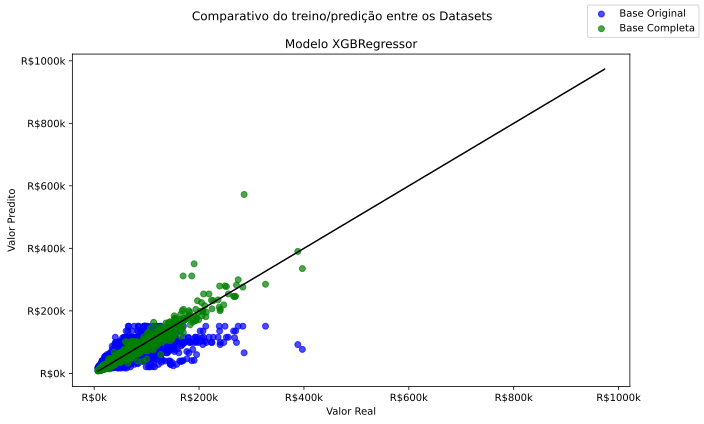

In [41]:
# Gráfico comparando o treinamento/predição para diferentes Dataset

y_hat = trained_models["XGBRegressor"]["predict"]
y_hat_o = trained_models_orig["XGBRegressor"]["predict"]

fig, ax = plt.subplots(figsize=(10,6))

sample = min(2000, len(y_test))
idx = np.random.choice(len(y_test), sample, replace=False)

ax.scatter(y_test_o.values[idx], y_hat_o[idx], alpha=0.7, color='b', label='Base Original')
ax.scatter(y_test.values[idx], y_hat[idx], alpha=0.7, color='g', label='Base Completa')
ax.plot(
    [y_test_o.min(), y_test_o.max()],
    [y_test_o.min(), y_test_o.max()], color='k')

ax.set_xlabel("Valor Real")
ax.set_ylabel("Valor Predito")
ax.set_title("Modelo XGBRegressor")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))

fig.legend()

fig.suptitle("Comparativo do treino/predição entre os Datasets")

plt.show()